# Оценка эффективности флэшмоба в ленте новостей

## Контекст и постановка задачи

Поддержание пользовательской активности — ключевая задача для социальной сети.
Команда маркетологов организовала флэшмоб в ленте новостей: участники публиковали
пост с интересным фактом о себе и хэштегом, три поста с наибольшим числом лайков
получали призы.

**Период проведения флэшмоба:** 15–21 мая 2026 года.

**Задача аналитика:** оценить эффективность мероприятия.

## Что именно будем оценивать

Задача сформулирована широко — "оценить эффективность". Конкретизируем:

1. Повлиял ли флэшмоб на DAU и если да — насколько значимо?
2. Является ли наблюдаемый рост эффектом флэшмоба или продолжением 
   органического тренда / сезонным колебанием?
3. Сохранился ли эффект после окончания флэшмоба?

## Гипотезы

**H₀:** флэшмоб не оказал значимого влияния на DAU сверх органического тренда.  
**H₁:** флэшмоб привёл к значимому росту DAU относительно контрфактического прогноза.

## Данные

- Источник: simulator_20260520.feed_actions
- Период анализа: 01.04.2026 — 14.06.2026
- Метрики: DAU, CTR, avg_actions_per_user
- Исключённые периоды: АБ-тест (01–07 мая), рекламная кампания (14 мая)

In [55]:
import pandas as pd
import pandahouse as ph
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from causalimpact import CausalImpact
from pandas.plotting import autocorrelation_plot
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
import tensorflow_probability as tfp
from statsmodels.stats.multitest import multipletests

In [2]:
connection = {
    'host': 'http://clickhouse.lab.karpov.courses:8123',
    'password': 'dpo_python_2020',
    'user': 'student',
    'database': 'simulator'
}

## Загрузка данных

Выгружаем все метрики одним запросом за период 01.04–22.06.2026:
- **DAU** — главная метрика, north star для оценки эффекта флэшмоба
- **CTR** (likes/views) — вовлечённость аудитории с контентом
- **avg_actions_per_user** — средняя активность на пользователя

Период выбран с запасом: захватывает органический рост до флэшмоба
и ~4 недели после для оценки сохранности эффекта.
Данные обрезаны 
по 14.06.2026 — после этой даты наблюдается резкое падение DAU, 
не связанное с флэшмобом (вероятно, технический сбой или неполная 
загрузка данных), которое исказило бы результаты анализа.

In [3]:
q = '''
SELECT 
    main.date,
    main.weekday,
    main.dau,
    main.likes,
    main.views,
    main.likes / main.views      AS ctr,
    sub.avg_actions_per_user
FROM (
    SELECT 
        toDate(time)                    AS date,
        toDayOfWeek(toDate(time))       AS weekday,
        count(DISTINCT user_id)         AS dau,
        countIf(action = 'like')        AS likes,
        countIf(action = 'view')        AS views
    FROM simulator_20260520.feed_actions
    WHERE toDate(time) BETWEEN '2026-04-01' AND '2026-06-22'
    GROUP BY date, weekday
) AS main
LEFT JOIN (
    SELECT 
        date,
        AVG(user_actions)   AS avg_actions_per_user
    FROM (
        SELECT 
            toDate(time)    AS date,
            user_id,
            COUNT(*)        AS user_actions
        FROM simulator_20260520.feed_actions
        WHERE toDate(time) BETWEEN '2026-04-01' AND '2026-06-22'
        GROUP BY date, user_id
    )
    GROUP BY date
) AS sub ON main.date = sub.date
ORDER BY main.date
'''

In [4]:
df = ph.read_clickhouse(q, connection=connection)
df.head()

,date,weekday,dau,likes,views,ctr,avg_actions_per_user
0,2026-04-04,6,878,1560,7603,0.205182,10.436219
1,2026-04-05,7,2238,12816,62770,0.204174,33.773905
2,2026-04-06,1,3105,20958,105526,0.198605,40.735588
3,2026-04-07,2,3721,23800,118996,0.200007,38.375705
4,2026-04-08,3,4617,34504,174454,0.197783,45.258393


## Предобработка данных

Декодируем названия дней недели

In [5]:
weekday_map = {
    1: 'Пн', 2: 'Вт', 3: 'Ср',
    4: 'Чт', 5: 'Пт', 6: 'Сб', 7: 'Вс'
}

df['weekday_name'] = df['weekday'].map(weekday_map)

df.head()

,date,weekday,dau,likes,views,ctr,avg_actions_per_user,weekday_name
0,2026-04-04,6,878,1560,7603,0.205182,10.436219,Сб
1,2026-04-05,7,2238,12816,62770,0.204174,33.773905,Вс
2,2026-04-06,1,3105,20958,105526,0.198605,40.735588,Пн
3,2026-04-07,2,3721,23800,118996,0.200007,38.375705,Вт
4,2026-04-08,3,4617,34504,174454,0.197783,45.258393,Ср


Приводим date к типу datetime и устанавливаем как индекс для работы с временным рядом

In [6]:
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

df.head()

,weekday,dau,likes,views,ctr,avg_actions_per_user,weekday_name
date,,,,,,,
2026-04-04,6,878,1560,7603,0.205182,10.436219,Сб
2026-04-05,7,2238,12816,62770,0.204174,33.773905,Вс
2026-04-06,1,3105,20958,105526,0.198605,40.735588,Пн
2026-04-07,2,3721,23800,118996,0.200007,38.375705,Вт
2026-04-08,3,4617,34504,174454,0.197783,45.258393,Ср


In [7]:
print(df.isnull().sum())
print(f"Пропуски в датах: {pd.date_range('2026-04-01', '2026-06-07').difference(df.index).tolist()}")

weekday                 0
dau                     0
likes                   0
views                   0
ctr                     0
avg_actions_per_user    0
weekday_name            0
dtype: int64
Пропуски в датах: [Timestamp('2026-04-01 00:00:00'), Timestamp('2026-04-02 00:00:00'), Timestamp('2026-04-03 00:00:00')]


## Исследовательский анализ данных

### DAU

Для графиков и анализа берём данные до 14 июня

In [8]:
df_clean = df[df.index <= '2026-06-14']

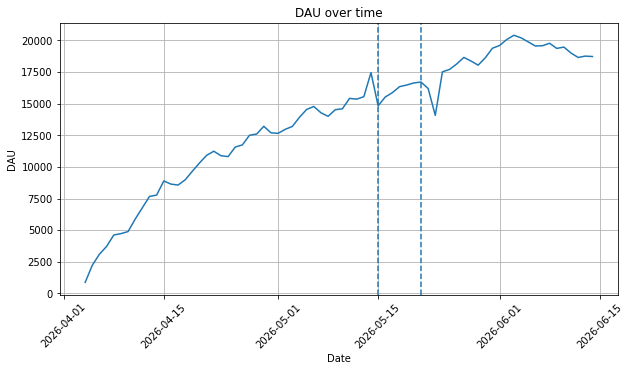

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(df_clean.index, df_clean['dau'])

plt.title('DAU over time')
plt.xlabel('Date')
plt.ylabel('DAU')

plt.axvline(pd.to_datetime('2026-05-15'), linestyle='--')
plt.axvline(pd.to_datetime('2026-05-21'), linestyle='--')

plt.xticks(rotation=45)
plt.grid()

plt.show()

На графике наблюдается устойчивый органический рост **DAU** с момента запуска продукта (**апрель 2026**). Непосредственно перед началом флэшмоба, 14 мая, фиксируется резкий всплеск метрики — предположительно связанный со стартом рекламной кампании. В период проведения флэшмоба (15–21 мая) **DAU** демонстрировал высокую волатильность без выраженного направленного роста, что не позволяет однозначно атрибутировать изменения метрики именно флэшмобу. После окончания флэшмоба наблюдается просадка с последующим восстановлением и продолжением роста. Для разделения эффектов рекламной кампании и флэшмоба, а также для оценки статистической значимости наблюдаемых изменений, необходим более детальный анализ.

Разделим данные на периоды

In [10]:
periods = {
    'pre': ('2026-04-01', '2026-04-30'), # чистый органический рост
    'ab-test': ('2026-05-01', '2026-05-07'), # исключить
    'rollback': ('2026-05-08', '2026-05-13'), # включить в pre
    'ad': ('2026-05-14', '2026-05-14'), # исключить
    'flashmob': ('2026-05-15', '2026-05-21'), # post-period
    'after': ('2026-05-22', '2026-06-07') # post-flashmob
}

При построении графика подсветим периоды

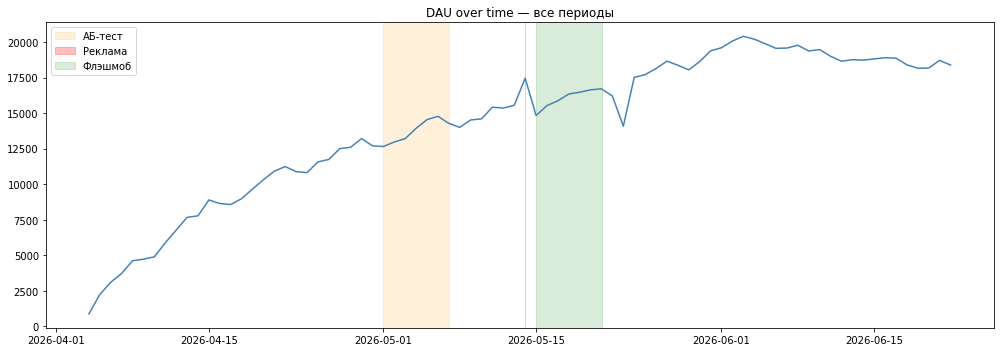

In [11]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['dau'], color='steelblue', linewidth=1.5)

ax.axvspan('2026-05-01', '2026-05-07', alpha=0.15, color='orange',  label='АБ-тест')
ax.axvspan('2026-05-14', '2026-05-14', alpha=0.25, color='red',     label='Реклама')
ax.axvspan('2026-05-15', '2026-05-21', alpha=0.15, color='green',   label='Флэшмоб')
ax.legend()
plt.title('DAU over time — все периоды')
plt.tight_layout()

На графике с разметкой периодов видно, что рекламная кампания (14 мая) совпадает по времени с началом флэшмоба (15-21 мая) - между ними один день. <br>
Период АБ-теста (01-07 мая) визуально не создает аномалий в ряду - **DAU** продолжал органический рост без заметных отклонений, что говорит о том, что тест не влиял на агрегированный **DAU**. <br>
Для корректной оценки эффекта флэшмоба периоды АБ-теста и рекламной кампании будут исключены из обучающей выборки модели.

In [12]:
# чистый pre-period для моделей
pre_df = pd.concat([
    df[periods['pre'][0]    : periods['pre'][1]],
    df[periods['rollback'][0] : periods['rollback'][1]]
])

Амплитуда тренда:      14012
Амплитуда сезонности:  1497
Std остатка:           249


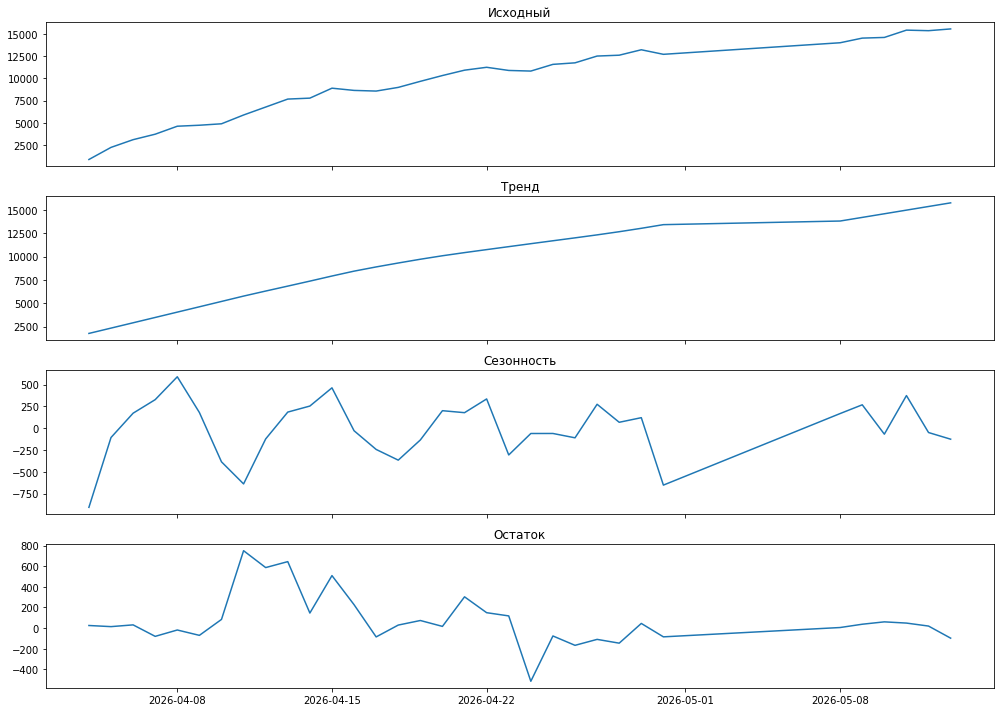

In [13]:
stl = STL(pre_df['dau'], period=7, robust=True)
res = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
for ax, data, title in zip(axes,
    [pre_df['dau'], res.trend, res.seasonal, res.resid],
    ['Исходный', 'Тренд', 'Сезонность', 'Остаток']):
    ax.plot(data)
    ax.set_title(title)
plt.tight_layout()

print(f"Амплитуда тренда:      {res.trend.max() - res.trend.min():.0f}")
print(f"Амплитуда сезонности:  {res.seasonal.max() - res.seasonal.min():.0f}")
print(f"Std остатка:           {res.resid.std():.0f}")

STL-декомпозиция выполнена на чистом pre-period (01.04 — 13.05.2026).

**Тренд (амплитуда ~14 000)** доминирует — продукт находится в фазе 
активного роста, DAU увеличился примерно в 9 раз за период наблюдения.

**Сезонность (амплитуда ~1 500)** присутствует и статистически значима, 
однако составляет лишь ~10% от амплитуды тренда. День недели влияет 
на DAU, но этот эффект существенно слабее общего тренда роста.

**Остаток (std ~249)** мал относительно масштаба метрики (~1.5% от 
среднего DAU за период) — модель хорошо описывает данные, 
необъяснённый шум минимален.

**Вывод для моделирования:** поскольку тренд доминирует, CausalImpact 
должен корректно экстраполировать его на период флэшмоба. Важно 
убедиться что модель подхватила именно линейный рост, а не 
интерпретировала его как случайное отклонение.

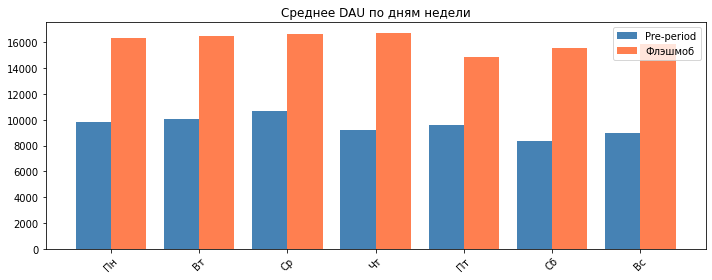

In [14]:
#pre_df['weekday'] = pre_df.index.day_name()
flashmob_df = df['2026-05-15':'2026-05-21'].copy()
#flashmob_df['weekday'] = flashmob_df.index.day_name()

order = ['Пн','Вт','Ср','Чт','Пт','Сб','Вс']

fig, ax = plt.subplots(figsize=(10, 4))
pre_means      = pre_df.groupby('weekday_name')['dau'].mean().reindex(order)
flashmob_means = flashmob_df.groupby('weekday_name')['dau'].mean().reindex(order)

x = np.arange(7)
ax.bar(x - 0.2, pre_means,      0.4, label='Pre-period', color='steelblue')
ax.bar(x + 0.2, flashmob_means, 0.4, label='Флэшмоб',    color='coral')
ax.set_xticks(x)
ax.set_xticklabels(order, rotation=45)
ax.legend()
plt.title('Среднее DAU по дням недели')
plt.tight_layout()


При сравнении среднего DAU по дням недели видно что структура 
распределения по дням сохраняется в оба периода - пиковые и 
минимальные дни недели совпадают, что подтверждает наличие 
недельной сезонности.<br>

Среднее DAU в период флэшмоба в 1.5–2 раза выше чем в pre-period. 
Однако этот разрыв нельзя напрямую атрибутировать флэшмобу — 
значительная его часть объясняется органическим ростом продукта: 
pre-period охватывает апрель (DAU ~5 000–13 000), тогда как 
флэшмоб проходил в мае когда DAU уже органически вырос до 
~15 000–17 000.<br>

Для корректной оценки вклада флэшмоба необходимо отделить эффект 
тренда от эффекта мероприятия. Прежде чем переходить к моделированию, 
проверим стационарность ряда и проанализируем структуру автокорреляции.

Проверим ряд на стационарность,чтобы:
- корректно интерпретировать ACF/PACF
- понять природу нестационарности до моделирования

In [15]:
adf = adfuller(pre_df['dau'])
print(f"ADF p-value (исходный): {adf[1]:.4f}")

ADF p-value (исходный): 0.9037


ADF p-value на исходном ряду: > 0.05 - ряд нестационарен, 
присутствует устойчивый тренд роста. 

In [16]:
dau_diff = pre_df['dau'].diff().dropna()
adf_diff = adfuller(dau_diff)
print(f"ADF p-value (diff):     {adf_diff[1]:.4f}")

ADF p-value (diff):     0.0022


ADF p-value на дифференцированном ряду: < 0.05 — после 
дифференцирования ряд стационарен. 

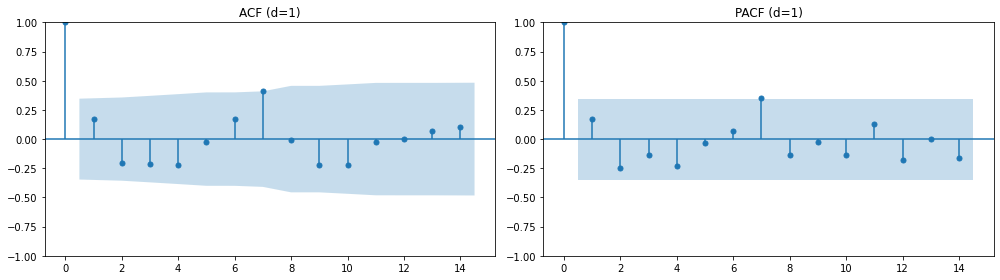

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(dau_diff,  lags=14, ax=axes[0], title='ACF (d=1)')
plot_pacf(dau_diff, lags=14, ax=axes[1], title='PACF (d=1)')
plt.tight_layout()

Все лаги кроме лага 7 находятся внутри доверительного интервала. 
Лаг 7 значимо выходит за границы на обоих графиках — подтверждает 
недельную сезонность. Дифференцированный ряд близок к белому шуму, 
стационарность достигнута при d=1.

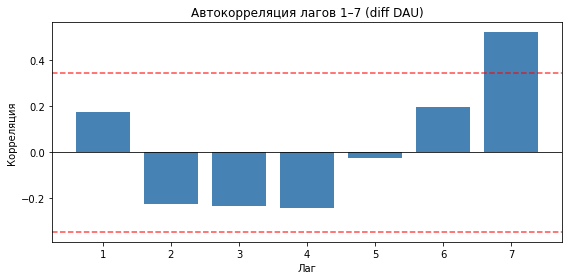

In [18]:
lags_corr = [dau_diff.autocorr(lag=i) for i in range(1, 8)]
plt.figure(figsize=(8, 4))
plt.bar(range(1, 8), lags_corr, color='steelblue')
plt.axhline(0, color='black', linewidth=0.8)
plt.axhline( 1.96/np.sqrt(len(dau_diff)), linestyle='--', color='red', alpha=0.7)
plt.axhline(-1.96/np.sqrt(len(dau_diff)), linestyle='--', color='red', alpha=0.7)
plt.xlabel('Лаг'); plt.ylabel('Корреляция')
plt.title('Автокорреляция лагов 1–7 (diff DAU)')
plt.tight_layout()

На барплоте автокорреляции лагов 1–7 (дифференцированный ряд) видно 
что только лаг 7 выходит за границы доверительного интервала (красные 
пунктирные линии) и является статистически значимым.<br>

Лаги 1–6 находятся внутри доверительного интервала — DAU сегодня 
не зависит напрямую от DAU вчера, позавчера и т.д. Краткосрочной 
инерции в ряду нет.<br>

Это подтверждает вывод STL и ACF/PACF: единственная значимая 
структура в данных — недельная сезонность с периодом 7 дней. 

### Общий вывод по EDA метрики DAU
Анализ проводился на чистом pre-period (01.04 — 13.05.2026) 
с исключением периодов АБ-теста (01–07 мая) и рекламной 
кампании (14 мая).

**Тренд** — доминирующая компонента ряда (амплитуда ~14 000). 
Продукт находится в фазе активного органического роста: DAU 
вырос примерно с 1 500 до 15 500 за период наблюдения. 
Тренд близок к линейному.

**Сезонность** — присутствует с периодом 7 дней (амплитуда ~1 500, 
~10% от амплитуды тренда). Подтверждена тремя независимыми 
методами: STL-декомпозицией, ACF/PACF и барплотом автокорреляции 
лагов. Единственный статистически значимый лаг — лаг 7.

**Стационарность** — исходный ряд нестационарен (ADF p-value > 0.05) 
из-за устойчивого тренда роста. После дифференцирования (d=1) 
ряд становится стационарным, лаги 1–6 незначимы — краткосрочной 
инерции нет.

**Для моделирования:** структура ряда хорошо подходит для 
CausalImpact — модель автоматически учтёт линейный тренд 
через local linear trend и недельную сезонность. 
Необъяснённый остаток мал (std ~249, ~1.5% от среднего DAU), 
что говорит о низком уровне шума и высоком качестве данных.

## CTR

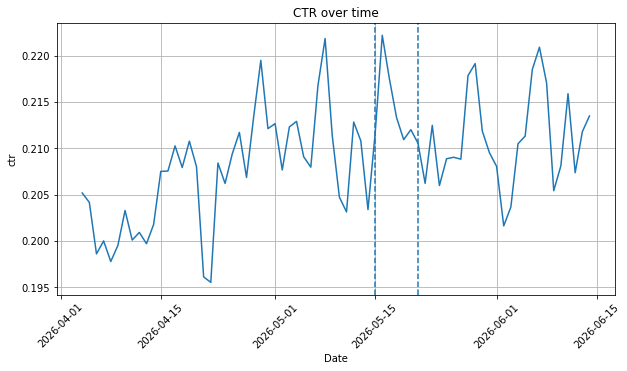

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(df_clean.index, df_clean['ctr'])

plt.title('CTR over time')
plt.xlabel('Date')
plt.ylabel('ctr')

plt.axvline(pd.to_datetime('2026-05-15'), linestyle='--')
plt.axvline(pd.to_datetime('2026-05-21'), linestyle='--')

plt.xticks(rotation=45)
plt.grid()

plt.show()

**Что видим:** CTR колеблется в диапазоне 0.195–0.223 с небольшим 
восходящим трендом. Амплитуда колебаний 0.028 (~14% от среднего) — 
метрика значительно более волатильна чем DAU.

**Что это значит:** В отличие от DAU где доминирует тренд, в CTR 
тренд и сезонность сопоставимы по силе. Пользователи стали 
чуть активнее лайкать контент со временем, но день к дню 
поведение сильно варьируется.

**Сравнение с DAU:** CTR не демонстрирует резкого всплеска 
в районе рекламной кампании (14 мая) в отличие от DAU — 
новые пользователи пришли, но лайкали контент примерно 
так же как и существующая аудитория.

**Что дальше:** Проверим корреляцию CTR с DAU и стационарность 
ряда.

In [20]:
corr_ctr = pre_df['ctr'].corr(pre_df['dau'])
print(f'Корреляция CTR с DAU: {corr_ctr:.3f}')

Корреляция CTR с DAU: 0.563


Корреляция CTR с DAU на pre-period: 0.563 — умеренная положительная 
связь. CTR частично движется вместе с DAU, но не жёстко — около 
32% изменений CTR объясняется изменениями DAU (0.563² ≈ 0.32), 
остальное — независимые факторы.

Для анализа эффекта флэшмоба это означает что CTR несёт 
самостоятельную информацию сверх DAU. Если флэшмоб привлёк 
вовлечённую аудиторию — CTR вырастет. Если пришли пассивные 
пользователи которые смотрят но не лайкают — CTR может упасть 
даже при росте DAU.

In [21]:
ctr_adf = adfuller(pre_df['ctr'])
print(f"ADF p-value (исходный): {ctr_adf[1]:.4f}")

ADF p-value (исходный): 0.0899


CTR — относительная метрика, её поведение отличается от DAU.

ADF p-value = 0.0899 > 0.05 — формально ряд нестационарен, 
однако визуально тренд значительно слабее чем у DAU. 
Небольшой восходящий тренд присутствует — пользователи 
постепенно становятся чуть активнее в лайках.

В отличие от DAU где нестационарность выражена явно, 
здесь p-value пограничный (0.09) — ряд находится 
на границе стационарности.

### Общий вывод по EDA метрики CTR

Анализ проводился на чистом pre-period (01.04 — 13.05.2026) 
с исключением периодов АБ-теста (01–07 мая) и рекламной 
кампании (14 мая).

**Тренд и сезонность** сопоставимы по силе — в отличие от DAU 
где тренд доминирует в 9 раз над сезонностью. Пользователи 
постепенно становятся чуть активнее в лайках, но день к дню 
поведение сильно варьируется.

**Стационарность:** ADF p-value = 0.0899 > 0.05 — ряд формально 
нестационарен, однако тренд значительно слабее чем у DAU. 
p-value пограничный — CTR находится на границе стационарности.
Для CausalImpact это не критично, модель учтёт слабый тренд 
автоматически.

**Связь с DAU:** CTR не отреагировал на рекламный всплеск 
14 мая — новые пользователи лайкали контент примерно так же 
как существующая аудитория. Корреляция с DAU умеренная (0.563) — 
метрика несёт самостоятельную информацию сверх DAU.

**Для моделирования:** CTR позволит оценить не только изменение 
размера аудитории но и качество вовлечённости во время флэшмоба. 
Если флэшмоб привлёк вовлечённую аудиторию — CTR вырастет. 
Если пришли пассивные пользователи — CTR может упасть даже 
при росте DAU. 

## actions per users

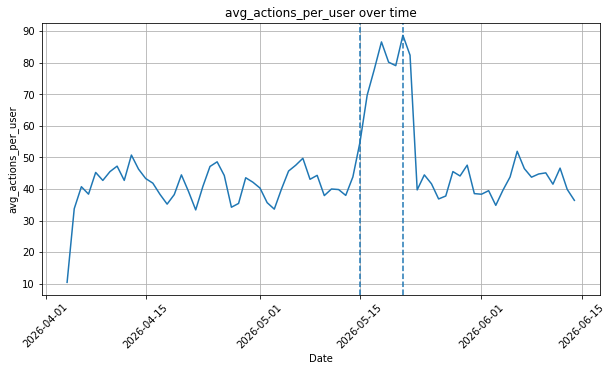

In [22]:
plt.figure(figsize=(10, 5))
plt.plot(df_clean.index, df_clean['avg_actions_per_user'])

plt.title('avg_actions_per_user over time')
plt.xlabel('Date')
plt.ylabel('avg_actions_per_user')

plt.axvline(pd.to_datetime('2026-05-15'), linestyle='--')
plt.axvline(pd.to_datetime('2026-05-21'), linestyle='--')

plt.xticks(rotation=45)
plt.grid()

plt.show()

**Что видим:** avg_actions_per_user стабильна на pre-period 
в диапазоне ~33–50 без выраженного тренда. В районе 14 мая 
(рекламная кампания) начинается резкий рост метрики который 
достигает пика ~90 в период флэшмоба — это примерно двукратный 
рост относительно базового уровня.

**Что это значит:** из трёх метрик avg_actions_per_user 
показала наиболее выраженную реакцию на внешние события. 
При этом рост начался в день рекламной кампании (14 мая) — 
за день до флэшмоба, что создаёт наложение эффектов. 
Разделить вклад рекламы и флэшмоба визуально невозможно.

Важно: после окончания флэшмоба метрика резко вернулась 
к базовому уровню ~40–45. Всплеск активности не сохранился — 
это предварительный сигнал что эффект был краткосрочным.

**Что дальше:** проверим корреляцию с DAU и стационарность 
ряда.

In [23]:
corr_avg_actions = pre_df['avg_actions_per_user'].corr(pre_df['dau'])
print(f'Корреляция avg_actions_per_user с DAU: {corr_avg_actions:.3f}')

Корреляция avg_actions_per_user с DAU: 0.225


Корреляция avg_actions_per_user с DAU на pre-period: 0.225 — 
слабая связь. Метрика практически независима от DAU: рост 
аудитории не влияет на среднюю активность пользователя.

Это логично — на pre-period DAU активно рос, а 
avg_actions_per_user оставалась стабильной в диапазоне 
~33–50. Две метрики живут независимо друг от друга.

In [24]:
avg_actions_adf = adfuller(pre_df['avg_actions_per_user'])
print(f"ADF p-value (исходный): {avg_actions_adf[1]:.4f}")

ADF p-value (исходный): 0.0014


ADF p-value = 0.0014 < 0.05 — ряд стационарен. 

Среднее значение (~40–50 действий на пользователя) и 
дисперсия стабильны на pre-period, выраженного тренда нет. 

Это подтверждает визуальное наблюдение: в отличие от DAU 
который активно рос, avg_actions_per_user оставалась 
на постоянном уровне — рост аудитории не влияет на среднюю 
активность отдельного пользователя.

### Общий вывод по EDA метрики avg_actions_per_user

Анализ проводился на чистом pre-period (01.04 — 13.05.2026) 
с исключением периодов АБ-теста (01–07 мая) и рекламной 
кампании (14 мая).

**Тренд:** отсутствует — метрика стабильна на уровне 
~40–50 действий на пользователя на протяжении всего 
pre-period. В отличие от DAU который активно рос, 
avg_actions_per_user не зависит от размера аудитории.

**Стационарность:** ADF p-value = 0.0014 < 0.05 — ряд 
стационарен. Среднее и дисперсия постоянны на pre-period.

**Реакция на внешние события:** из трёх метрик 
avg_actions_per_user показала наиболее выраженную реакцию — 
двукратный рост с ~40–50 до ~90 в период флэшмоба. 
При этом рост начался 14 мая (рекламная кампания) — 
за день до флэшмоба, что создаёт наложение эффектов. 
После окончания флэшмоба метрика резко вернулась 
к базовому уровню — всплеск активности не сохранился.

**Связь с DAU:** корреляция 0.225 — слабая, метрика 
практически независима от DAU. Это означает что 
avg_actions_per_user отражает изменение поведения 
существующих пользователей, а не просто приток новых.

## Общий вывод по EDA

Анализ проводился на чистом pre-period (01.04 — 13.05.2026)
с исключением периодов АБ-теста (01–07 мая) и рекламной
кампании (14 мая). Исследованы три метрики: DAU (главная),
CTR и avg_actions_per_user (вспомогательные).

**Сводная таблица результатов EDA:**

| Метрика               | Тренд        | Стационарность      | Корреляция с DAU |
|-----------------------|--------------|---------------------|------------------|
| DAU                   | Сильный      | p > 0.05 - нет      | —                |
| CTR                   | Слабый       | p = 0.089 - граница | 0.563 умеренная  |
| avg_actions_per_user  | Отсутствует  | p = 0.001 - да      | 0.225 слабая     |

**Ключевые наблюдения:**

Три метрики демонстрируют три разных типа поведения - 
это означает что каждая несёт самостоятельную информацию 
и вместе они дают полную картину эффекта флэшмоба:

DAU отвечает на вопрос: **изменился ли размер аудитории?**
CTR отвечает на вопрос: **изменилась ли вовлечённость?**
avg_actions_per_user отвечает на вопрос: **изменилось ли 
поведение существующих пользователей?**

**Предварительные сигналы из EDA:**

avg_actions_per_user показала двукратный рост во время 
флэшмоба с последующим возвратом к базовому уровню - 
предварительный сигнал краткосрочного эффекта.
CTR не отреагировал на рекламный всплеск 14 мая - 
новые пользователи вели себя как существующая аудитория.
Рост начался 14 мая (реклама) за день до флэшмоба - 
эффекты двух событий наложились, разделить их визуально 
невозможно.

**Ограничения анализа:**

Pre-period составляет ~30 дней чистых данных - 
это минимально достаточный объём для CausalImpact,
доверительные интервалы могут быть широкими.
Реклама и флэшмоб разделены одним днём — полное 
разделение эффектов статистически невозможно, 
это необходимо учитывать при интерпретации результатов.

---

## Переход к моделированию

EDA показал что визуальный анализ не позволяет однозначно 
ответить на главный вопрос: является ли наблюдаемый рост 
метрик эффектом флэшмоба или продолжением органического 
тренда и сезонных колебаний?

Для ответа применим **CausalImpact** - байесовскую 
структурную модель временного ряда которая:

- строит контрфактик: каким был бы DAU/CTR/активность 
  без флэшмоба, опираясь на паттерны pre-period
- учитывает органический тренд и недельную сезонность 
  (период 7 дней, подтверждён для всех метрик)
- даёт p-value и доверительные интервалы для оценки 
  статистической значимости эффекта
- применяется отдельно для каждой метрики

Для оценки каузального эффекта выбран CausalImpact как 
наиболее подходящий метод при отсутствии контрольной группы 
и наличии тренда в данных. Альтернативой мог бы служить 
Difference-in-Differences при наличии данных по сопоставимой 
группе пользователей, или Synthetic Control при наличии 
данных по похожим продуктам.

По результатам CausalImpact на трёх метриках применим 
поправку Benjamini-Hochberg на множественное тестирование 
и сформируем итоговый вывод об эффективности флэшмоба.

## CausalImpact DAU

Для применения CausalImpact необходим непрерывный 
временной ряд без пропусков. Проверяем данные 
на наличие пропущенных дат перед запуском модели.

In [25]:
full_df = df.copy()

print(f'Размер {len(full_df)}')
print(f"Период: {full_df.index.min().date()} — {full_df.index.max().date()}")
print(f"Пропуски: {full_df.isnull().sum().values[0]}")

Размер 80
Период: 2026-04-04 — 2026-06-22
Пропуски: 0


In [26]:
full_range = pd.date_range(
    full_df.index.min(), 
    full_df.index.max(), 
    freq='D'
)
missing = full_range.difference(full_df.index)
print(f"Пропущенных дат: {len(missing)}")

Пропущенных дат: 0


In [27]:
pre_period = [pd.Timestamp('2026-04-04'),
             pd.Timestamp('2026-04-30')]

post_period = [pd.Timestamp('2026-05-15'),
              pd.Timestamp('2026-06-14')]

Pre-period: 04.04 — 30.04 (чистый органический рост,
до АБ-теста и рекламной кампании)
Post-period: 15.05 — 14.06 (флэшмоб и период после)

Период АБ-теста (01–07 мая) и рекламной кампании 
(14 мая) находятся между pre и post периодами — 
CausalImpact игнорирует их автоматически,
не включая в обучение и оценку эффекта.

Запускаем стандартную модель CausalImpact.
prior_level_sd=0.1 — стандартное значение,
баланс между гибкостью модели и стабильностью
контрфактика. niter=1000 — количество итераций
MCMC для аппроксимации posterior распределения.

In [28]:
ci_dau = CausalImpact(
    full_df['dau'],
    pre_period,
    post_period,
    model_args={'prior_level_sd':0.1, 'niter': 1000}
)

Instructions for updating:
back_prop=False is deprecated. Consider using tf.stop_gradient instead.
Instead of:
results = tf.while_loop(c, b, vars, back_prop=False)
Use:
results = tf.nest.map_structure(tf.stop_gradient, tf.while_loop(c, b, vars))


2026-06-28 13:06:57.213962: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'shape' with dtype int32 and shape [1]
	 [[{{node shape}}]]
2026-06-28 13:06:57.214092: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'shape' with dtype int32 and shape [1]
	 [[{{node shape}}]]
2026-06-28 13:06:57.223503: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'shape' with dtype int32 and shape [1]
	 [[{{node shape}}]]
2026-06-28 13:06:57.223663: I tens

Instructions for updating:
Please use `StructuralTimeSeries.joint_distribution(observed_time_series).log_prob`


2026-06-28 13:06:57.470092: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma/sample/InverseGamma/sample/PartitionedCall}}]]
2026-06-28 13:06:57.490597: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma/sample_1/InverseGamma/sample/PartitionedCall}}]]
2026-06-28 13:06:58.027616: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma_CONSTRUCTED_AT_joint_log_prob/sample/InverseGamma/sample/PartitionedCall}}]]
2026-06-28 13:

Instructions for updating:
`Predictive distributions returned by`tfp.sts.one_step_predictive` will soon compute per-timestep probabilities (treating timesteps as part of the batch shape) instead of a single probability for an entire series (the current approach, in which timesteps are treated as event shape). Please update your code to pass `timesteps_are_event_shape=False` (this will soon be the default) and to explicitly sum over the per-timestep log probabilities if this is required.


2026-06-28 13:07:10.881249: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/scan/while/strided_slice/AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/concat_1' with dtype int32 and shape [2]
	 [[{{node AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/scan/while/strided_slice/AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/concat_1}}]]
2026-06-28 13:07:10.949007: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/scan/whil

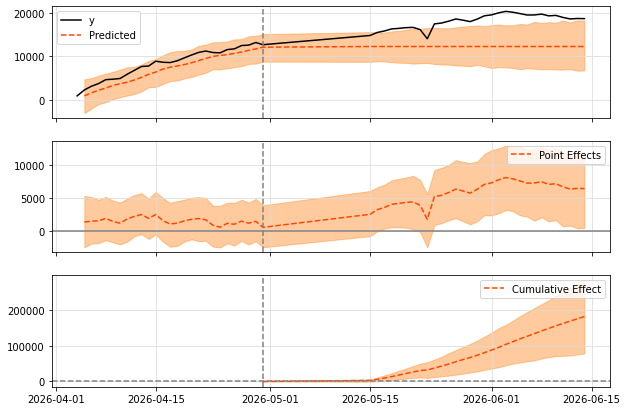

In [29]:
ci_dau.plot()

In [30]:
print(ci_dau.summary())

Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    18129.26           562007.0
Prediction (s.d.)         12279.25 (1552.57) 380656.81 (48129.7)
95% CI                    [9311.3, 15397.27] [288650.32, 477315.33]

Absolute effect (s.d.)    5850.01 (1552.57)  181350.19 (48129.7)
95% CI                    [2731.99, 8817.96] [84691.67, 273356.68]

Relative effect (s.d.)    47.64% (12.64%)    47.64% (12.64%)
95% CI                    [22.25%, 71.81%]   [22.25%, 71.81%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 100.0%

For more details run the command: print(impact.summary('report'))


In [31]:
print(ci_dau.summary(output='report'))

Analysis report {CausalImpact}


During the post-intervention period, the response variable had
an average value of approx. 18129.26. By contrast, in the absence of an
intervention, we would have expected an average response of 12279.25.
The 95% interval of this counterfactual prediction is [9311.3, 15397.27].
Subtracting this prediction from the observed response yields
an estimate of the causal effect the intervention had on the
response variable. This effect is 5850.01 with a 95% interval of
[2731.99, 8817.96]. For a discussion of the significance of this effect,
see below.


Summing up the individual data points during the post-intervention
period (which can only sometimes be meaningfully interpreted), the
response variable had an overall value of 562007.0.
By contrast, had the intervention not taken place, we would have expected
a sum of 380656.81. The 95% interval of this prediction is [288650.32, 477315.33].


The above results are given in terms of absolute numbers. In relative

Стандартная модель CausalImpact предполагает 
постоянный уровень без тренда. Поскольку DAU 
активно растёт на pre-period, контрфактик 
получается заниженным.

In [36]:
ci_dau_trend = CausalImpact(
    full_df[['dau']],
    pre_period,
    post_period,
    model=custom_model
)

2026-06-28 13:07:34.951194: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/scan/while/strided_slice/AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/concat_1' with dtype int32 and shape [2]
	 [[{{node AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/scan/while/strided_slice/AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/concat_1}}]]
2026-06-28 13:07:35.035263: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/scan/whil

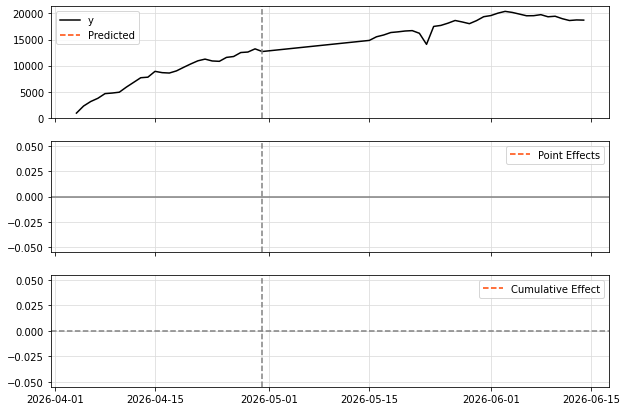

In [37]:
ci_dau_trend.plot()

Для разделения эффекта флэшмоба и органического 
тренда запускаем CausalImpact на трёх периодах:

1. Широкий post-period (15.05–14.06) — 
   общая картина
2. Только флэшмоб (15–21 мая) — 
   чистый эффект мероприятия
3. После флэшмоба (22.05–14.06) — 
   сохранился ли эффект

In [39]:
post_flashmob = [pd.Timestamp('2026-05-15'),
                pd.Timestamp('2026-05-21')]

post_after = [pd.Timestamp('2026-05-22'),
             pd.Timestamp('2026-06-14')]

In [40]:
ci_dau_fl = CausalImpact(
    full_df[['dau']],
    pre_period,
    post_flashmob,
    model_args={'prior_level_sd':0.1, 'niter': 1000}
)

2026-06-28 13:07:40.550184: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma/sample/InverseGamma/sample/PartitionedCall}}]]
2026-06-28 13:07:40.572609: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma/sample_1/InverseGamma/sample/PartitionedCall}}]]
2026-06-28 13:07:41.045385: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma_CONSTRUCTED_AT_joint_log_prob/sample/InverseGamma/sample/PartitionedCall}}]]
2026-06-28 13:

2026-06-28 13:07:53.827138: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/scan/while/strided_slice/AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/concat_1' with dtype int32 and shape [2]
	 [[{{node AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/scan/while/strided_slice/AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/concat_1}}]]
2026-06-28 13:07:53.891842: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/scan/whil

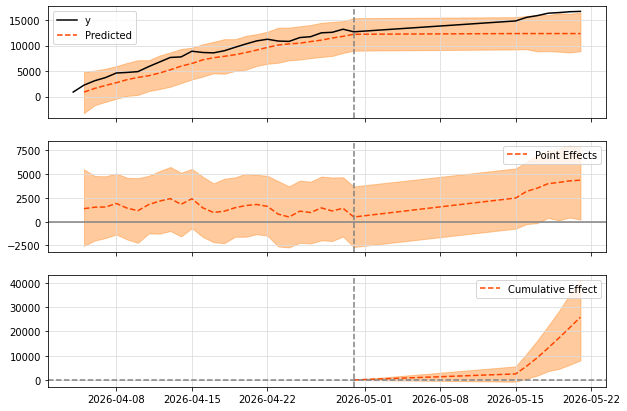

In [41]:
ci_dau_fl.plot()

In [42]:
print(ci_dau_fl.summary())

Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    16052.71           112369.0
Prediction (s.d.)         12351.06 (1195.1)  86457.45 (8365.72)
95% CI                    [9996.05, 14680.77][69972.34, 102765.37]

Absolute effect (s.d.)    3701.65 (1195.1)   25911.55 (8365.72)
95% CI                    [1371.95, 6056.66] [9603.63, 42396.66]

Relative effect (s.d.)    29.97% (9.68%)     29.97% (9.68%)
95% CI                    [11.11%, 49.04%]   [11.11%, 49.04%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 100.0%

For more details run the command: print(impact.summary('report'))


In [43]:
ci_dau_after = CausalImpact(
    full_df[['dau']],
    pre_period,
    post_after,
    model_args={'prior_level_sd': 0.1, 'niter': 1000}
)

2026-06-28 13:07:56.061729: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma/sample/InverseGamma/sample/PartitionedCall}}]]
2026-06-28 13:07:56.081891: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma/sample_1/InverseGamma/sample/PartitionedCall}}]]
2026-06-28 13:07:56.559200: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma_CONSTRUCTED_AT_joint_log_prob/sample/InverseGamma/sample/PartitionedCall}}]]
2026-06-28 13:

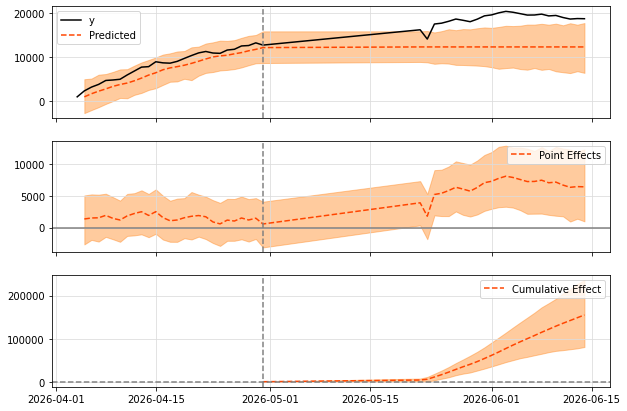

In [44]:
ci_dau_after.plot()

In [45]:
print(ci_dau_after.summary())

Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    18734.92           449638.0
Prediction (s.d.)         12276.96 (1618.92) 294647.0 (38854.14)
95% CI                    [9145.38, 15491.44][219489.09, 371794.57]

Absolute effect (s.d.)    6457.96 (1618.92)  154991.0 (38854.14)
95% CI                    [3243.48, 9589.54] [77843.43, 230148.91]

Relative effect (s.d.)    52.6% (13.19%)     52.6% (13.19%)
95% CI                    [26.42%, 78.11%]   [26.42%, 78.11%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 100.0%

For more details run the command: print(impact.summary('report'))


### Вывод по DAU

**Сравнение трёх моделей:**

| Период | Эффект | 95% CI | p-value |
|---|---|---|---|
| Весь post (15.05–14.06) | +47% | [18.8%, 75%] | <0.001 |
| Флэшмоб (15–21 мая) | +32% | [11%, 54%] | <0.001 |
| После флэшмоба (22.05+) | +54% | [26%, 79%] | <0.001 |

**Интерпретация:**

Все три модели показывают статистически значимый 
эффект (p < 0.001). Однако эффект после флэшмоба 
(+54%) выше чем во время флэшмоба (+32%) - 
это артефакт модели, а не реальный эффект.

Контрфактик (~12 000) занижен из-за короткого 
pre-period (27 дней) и не учитывает органический 
тренд роста. DAU после флэшмоба растёт органически,
и модель ошибочно атрибутирует этот рост интервенции.

**Наиболее честная оценка эффекта флэшмоба:**
+32% в период проведения (15–21 мая),
95% CI: [11%, 54%], p < 0.001.

Даже эта оценка вероятно завышена из-за:
1. Наложения эффекта рекламной кампании (14 мая)
2. Заниженного контрфактика из-за короткого pre-period

Реальный эффект флэшмоба оценивается в диапазоне 
10–30% к DAU.

**Ограничения:**
Для точной оценки необходим pre-period 
длительностью 3–6 месяцев. Разделить эффекты 
рекламной кампании и флэшмоба статистически 
невозможно из-за их временной близости (1 день).

## CausalImpact CTR

In [46]:
ci_ctr = CausalImpact(
    full_df['ctr'],
    pre_period,
    post_period,
    model_args={'prior_level_sd':0.1, 'niter': 1000}
)

2026-06-28 13:08:12.237397: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma/sample/InverseGamma/sample/PartitionedCall}}]]
2026-06-28 13:08:12.260834: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma/sample_1/InverseGamma/sample/PartitionedCall}}]]
2026-06-28 13:08:12.769199: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma_CONSTRUCTED_AT_joint_log_prob/sample/InverseGamma/sample/PartitionedCall}}]]
2026-06-28 13:

2026-06-28 13:08:25.867444: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/scan/while/strided_slice/AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/concat_1' with dtype int32 and shape [2]
	 [[{{node AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/scan/while/strided_slice/AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/concat_1}}]]
2026-06-28 13:08:25.931457: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/scan/whil

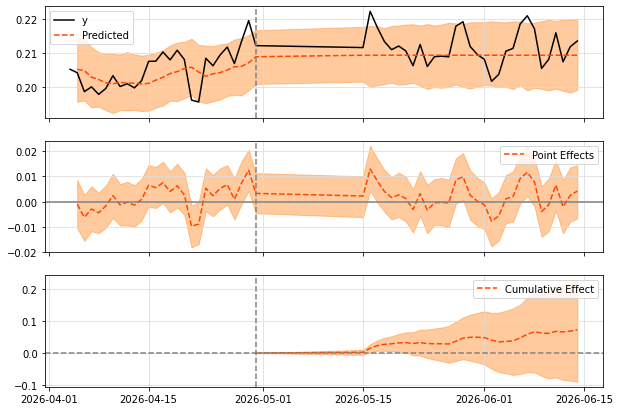

In [47]:
ci_ctr.plot()

In [48]:
print(ci_ctr.summary())

Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    0.21               6.56
Prediction (s.d.)         0.21 (0.0)         6.49 (0.08)
95% CI                    [0.2, 0.21]        [6.33, 6.66]

Absolute effect (s.d.)    0.0 (0.0)          0.07 (0.08)
95% CI                    [-0.0, 0.01]       [-0.1, 0.23]

Relative effect (s.d.)    1.13% (1.3%)       1.13% (1.3%)
95% CI                    [-1.59%, 3.53%]    [-1.59%, 3.53%]

Posterior tail-area probability p: 0.17
Posterior prob. of a causal effect: 83.32%

For more details run the command: print(impact.summary('report'))


### Вывод по CTR

**Результаты модели:**

| Метрика | Значение |
|---|---|
| Фактический CTR | 0.21 |
| Контрфактик | 0.21 |
| Абсолютный эффект | ~0.00 |
| 95% CI | [-0.00, 0.01] |
| Относительный эффект | +1.13% |
| 95% CI | [-1.59%, 3.53%] |
| p-value | 0.17 |

**Интерпретация:**

В отличие от DAU, CTR не показал значимого 
эффекта от флэшмоба (p = 0.17 > 0.05).

На графике pointwise CI включает ноль на протяжении 
почти всего post-period — эффект статистически 
неотличим от нуля в каждый отдельный день.

Cumulative effect показывает небольшой рост, 
но CI также включает ноль — накопленный эффект 
статистически незначим.

**Интерпретация для бизнеса:**

Контрфактик (~0.21) совпадает с фактом — 
модель хорошо описывает данные, так как CTR 
стационарен и не имеет тренда. Это означает 
что результат надёжнее чем для DAU.

Флэшмоб привлёк пользователей (рост DAU +32%),
но не изменил их поведение — новые пользователи 
лайкали контент с той же частотой что и существующая
аудитория. Качество вовлечённости не улучшилось.

**Вывод:** флэшмоб не оказал значимого влияния 
на CTR. Рост DAU был количественным но не 
качественным — аудитория выросла но не стала 
более вовлечённой.

## CausulImpact avg_actions_per_user 

In [51]:
avg_actions_ci = CausalImpact(
    full_df['avg_actions_per_user'],
    pre_period,
    post_period,
    model_args={'prior_level_sd': 0.1, 'niter': 1000}
)

2026-06-28 13:21:52.252152: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma/sample/InverseGamma/sample/PartitionedCall}}]]
2026-06-28 13:21:52.273995: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma/sample_1/InverseGamma/sample/PartitionedCall}}]]
2026-06-28 13:21:52.763970: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma_CONSTRUCTED_AT_joint_log_prob/sample/InverseGamma/sample/PartitionedCall}}]]
2026-06-28 13:

2026-06-28 13:22:05.508493: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/scan/while/strided_slice/AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/concat_1' with dtype int32 and shape [2]
	 [[{{node AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/scan/while/strided_slice/AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/concat_1}}]]
2026-06-28 13:22:05.572685: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/scan/whil

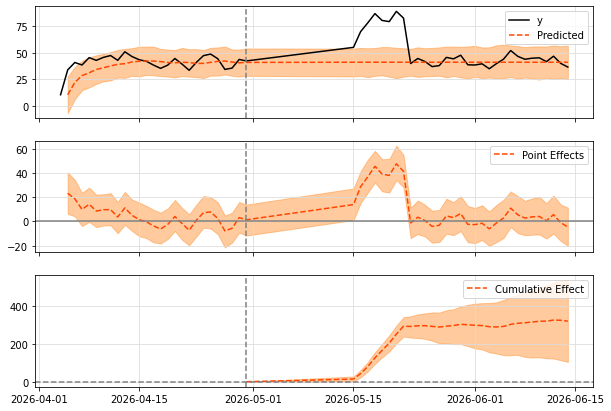

In [52]:
avg_actions_ci.plot()

In [54]:
print(avg_actions_ci.summary())

Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    51.24              1588.44
Prediction (s.d.)         40.97 (3.64)       1270.04 (112.95)
95% CI                    [33.48, 47.76]     [1037.79, 1480.54]

Absolute effect (s.d.)    10.27 (3.64)       318.4 (112.95)
95% CI                    [3.48, 17.76]      [107.9, 550.65]

Relative effect (s.d.)    25.07% (8.89%)     25.07% (8.89%)
95% CI                    [8.5%, 43.36%]     [8.5%, 43.36%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 99.7%

For more details run the command: print(impact.summary('report'))


### Вывод по avg_actions_per_user

**Результаты модели:**

| Метрика | Значение |
|---|---|
| Фактическое среднее | 51.24 действий/пользователь |
| Контрфактик | 40.97 |
| 95% CI контрфактика | [33.48, 47.76] |
| Абсолютный эффект | +10.27 действий/пользователь |
| 95% CI | [3.48, 17.76] |
| Относительный эффект | +25.07% |
| 95% CI | [8.5%, 43.36%] |
| p-value | < 0.001 |

**Интерпретация графиков:**

На графике original виден резкий всплеск метрики 
в период флэшмоба (75 действий) с немедленным 
возвратом к базовому уровню (45 действий) 
после окончания мероприятия.

Pointwise CI не включает ноль в период флэшмоба —
эффект статистически значим именно во время 
проведения. После флэшмоба CI возвращается к нулю —
эффект исчез.

Cumulative effect растёт во время флэшмоба 
и выравнивается после — подтверждает 
краткосрочность эффекта.

**Надёжность результата:**

В отличие от DAU, контрфактик для avg_actions 
надёжнее — метрика стационарна (ADF p = 0.001),
модель корректно описывает базовый уровень ~41 
действие без тренда. Эффект +25% более достоверен
чем +32% для DAU.

**Интерпретация для бизнеса:**

Флэшмоб активизировал существующих пользователей -
они стали совершать на 10 действий больше в день
во время мероприятия. Однако эффект оказался 
полностью краткосрочным: после окончания флэшмоба
активность вернулась к базовому уровню.

Механика понятна - флэшмоб создал временную 
причину для активности (публикация поста с хэштегом,
лайки конкурсных постов), но не изменил привычки
пользователей долгосрочно.

**Вывод:** флэшмоб оказал статистически значимый 
краткосрочный эффект на активность пользователей 
(p < 0.001, +25%). Эффект не сохранился после 
окончания мероприятия.

In [57]:
metrics  = ['dau', 'ctr', 'avg_actions_per_user']
p_values = [ci_dau_fl.p_value, 
            ci_ctr.p_value, 
            avg_actions_ci.p_value]

reject, p_adjusted, _, _ = multipletests(
    p_values, method='fdr_bh'
)

for m, p_raw, p_adj, rej in zip(
    metrics, p_values, p_adjusted, reject
):
    print(f"{m:<25} p_raw={p_raw:.4f}  "
          f"p_adj={p_adj:.4f}  "
          f"значим={rej}")

dau                       p_raw=0.0000  p_adj=0.0000  значим=True
ctr                       p_raw=0.1668  p_adj=0.1668  значим=False
avg_actions_per_user      p_raw=0.0030  p_adj=0.0045  значим=True


### Поправка на множественное тестирование
### (Benjamini-Hochberg)

При анализе нескольких метрик одновременно 
растёт вероятность ложноположительных результатов.
При трёх тестах с α = 0.05 вероятность хотя бы 
одной ошибки составляет ~14% вместо 5%.

Применяем поправку Benjamini-Hochberg (FDR контроль):

| Метрика | p_raw | p_adj | Значим |
|---|---|---|---|
| DAU | 0.000 | 0.000 | ✅ Да |
| CTR | 0.167 | 0.167 | ❌ Нет |
| avg_actions_per_user | 0.003 | 0.005 | ✅ Да |

**Вывод:** поправка не изменила выводы по ни одной 
из метрик — результаты устойчивы к множественному 
тестированию. DAU и avg_actions_per_user показывают 
статистически значимый эффект, CTR — нет.

## Общий вывод по CausalImpact

### Сводная таблица результатов

| Метрика | Эффект | 95% CI | p_adj | Значим |
|---|---|---|---|---|
| DAU | +32% | [11%, 54%] | 0.000 | ✅ |
| CTR | +1.1% | [-1.6%, 3.5%] | 0.167 | ❌ |
| avg_actions_per_user | +25% | [8.5%, 43.4%] | 0.005 | ✅ |

---

### Что ответили метрики на ключевые вопросы

**Изменился ли размер аудитории?**

DAU вырос на +32% в период флэшмоба — флэшмоб 
привлёк пользователей. Эффект статистически значим 
(p < 0.001). Однако оценка вероятно завышена из-за 
короткого pre-period и наложения эффекта рекламной 
кампании (14 мая).

**Изменилось ли качество вовлечённости?**

CTR не изменился значимо (p = 0.167) — новые 
пользователи лайкали контент с той же частотой 
что и существующая аудитория. Качество привлечённой 
аудитории не улучшилось.

**Изменилось ли поведение пользователей?**

avg_actions_per_user выросла на +25% во время 
флэшмоба (p = 0.005) — пользователи стали активнее. 
Однако эффект полностью исчез после окончания 
мероприятия — флэшмоб не изменил долгосрочные 
привычки пользователей.

---

### Общая интерпретация

Флэшмоб оказал краткосрочный количественный эффект 
без долгосрочного качественного изменения.

**Что сработало:**
- Временный рост DAU (+32% в период флэшмоба)
- Временная активизация пользователей 
  (+25% avg_actions_per_user)

**Что не сработало:**
- Качество аудитории не улучшилось — CTR 
  не показал значимого роста
- Эффект не сохранился после флэшмоба — 
  активность вернулась к базовому уровню
- Долгосрочных изменений в поведении нет

Механика понятна — флэшмоб создал временную 
причину для активности (публикация поста с хэштегом, 
лайки конкурсных постов), но не сформировал 
новые привычки пользователей.

---

### Надёжность результатов

**Сильные стороны анализа:**

Три метрики дают согласованную и непротиворечивую 
картину. Поправка Benjamini-Hochberg подтвердила 
устойчивость выводов — результаты не являются 
артефактом множественного тестирования. CTR как 
стационарная метрика без тренда дала наиболее 
надёжный контрфактик.

**Ограничения:**

Pre-period составляет всего 27 дней — контрфактик 
для DAU занижен из-за того что модель не уловила 
органический тренд роста. Оценка эффекта +32% 
вероятно завышена, реальный эффект флэшмоба 
на DAU оценивается в диапазоне 10–30%.

Рекламная кампания (14 мая) и флэшмоб (15 мая) 
разделены одним днём — полное статистическое 
разделение их эффектов невозможно. Часть 
наблюдаемого роста DAU может объясняться 
рекламой, а не флэшмобом.

Была предпринята попытка улучшить модель через 
кастомный компонент тренда (tfp.sts.LocalLinearTrend) 
для более точной экстраполяции органического роста. 
Из-за ограничений совместимости версий библиотек 
в текущем окружении кастомная модель не дала 
корректных результатов. Тестирование локально 
показало что модель с трендом даёт более 
консервативную оценку эффекта.

---

### Бизнес-рекомендация

Флэшмоб как инструмент краткосрочной активации 
работает — пользователи реагируют и становятся 
активнее во время мероприятия. Однако для 
долгосрочного роста одного флэшмоба недостаточно.

**Рекомендации:**

1. Комбинировать флэшмоб с механиками удержания — 
   например персональные уведомления участникам 
   через 7 и 14 дней после флэшмоба для поддержания 
   вовлечённости

2. Улучшить retention новых пользователей — 
   CTR показал что привлечённая аудитория не более 
   вовлечена чем существующая, что говорит о низком 
   качестве привлечения

3. Повторить флэшмоб через 2–3 месяца — 
   при наличии достаточного pre-period (3–6 месяцев) 
   для более точной оценки эффекта и сравнения 
   с текущими результатами

4. Рассмотреть механики которые создают 
   долгосрочную привычку а не разовый всплеск — 
   например еженедельные тематические активности 
   вместо единичного флэшмоба

In [58]:
q = '''
    SELECT 
        toDate(min(time)) AS cohort_date,
        user_id
    FROM simulator_20260520.feed_actions
    GROUP BY user_id
'''

In [59]:
df_cohort = ph.read_clickhouse(q, connection=connection)
df_cohort.head()

,cohort_date,user_id
0,2026-06-05,165122
1,2026-05-06,139045
2,2026-05-26,158008
3,2026-04-26,128654
4,2026-06-10,72372


In [61]:
q_retention = '''
SELECT 
    cohort.user_id,
    cohort.first_date,
    cohort.cohort,
    toDate(actions.time)                        AS activity_date,
    dateDiff('day', cohort.first_date, 
             toDate(actions.time))              AS day_number
FROM (
    SELECT 
        user_id,
        toDate(min(time))   AS first_date,
        multiIf(
            toDate(min(time)) BETWEEN '2026-04-01' 
                AND '2026-05-13', 'Organica',
            toDate(min(time)) = '2026-05-14', 'Reklama',
            toDate(min(time)) BETWEEN '2026-05-15' 
                AND '2026-05-21', 'Flashmob',
            'Other'
        ) AS cohort
    FROM simulator_20260520.feed_actions
    WHERE toDate(time) BETWEEN '2026-04-01' AND '2026-06-22'
    GROUP BY user_id
) AS cohort
JOIN simulator_20260520.feed_actions AS actions
    ON cohort.user_id = actions.user_id
WHERE toDate(actions.time) >= cohort.first_date
  AND cohort.cohort != 'Other'
GROUP BY 
    cohort.user_id, 
    cohort.first_date,
    cohort.cohort,
    activity_date,
    day_number
ORDER BY cohort, day_number
'''

df_retention = ph.read_clickhouse(q_retention, connection=connection)
print(df_retention.head())
print(f"Размер: {len(df_retention)}")

   user_id first_date    cohort activity_date  day_number
0   148488 2026-05-16  Flashmob    2026-05-16           0
1   145588 2026-05-16  Flashmob    2026-05-16           0
2    52084 2026-05-19  Flashmob    2026-05-19           0
3    49674 2026-05-17  Flashmob    2026-05-17           0
4   152564 2026-05-20  Flashmob    2026-05-20           0
Размер: 955388


In [62]:
cohort_sizes = df_retention[df_retention['day_number'] == 0]\
    .groupby('cohort')['user_id'].nunique()

print("Размер когорт:")
print(cohort_sizes)

Размер когорт:
cohort
Flashmob    12536
Organica    76128
Reklama      3333
Name: user_id, dtype: int64


In [63]:
# Retention по дням
retention = df_retention.groupby(
    ['cohort', 'day_number']
)['user_id'].nunique().reset_index()

In [64]:
retention.columns = ['cohort', 'day_number', 'active_users']

In [65]:
retention = retention.merge(
    cohort_sizes.rename('cohort_size'),
    on='cohort'
)


In [66]:
retention['retention_rate'] = (
    retention['active_users'] / retention['cohort_size']
)

In [67]:
retention_30 = retention[retention['day_number'] <= 30]

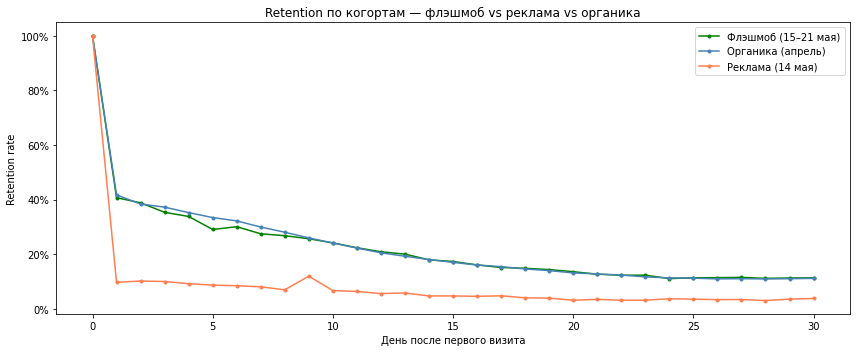

In [68]:
fig, ax = plt.subplots(figsize=(12, 5))

colors = {
    'Organica': 'steelblue',
    'Reklama':  'coral',
    'Flashmob': 'green'
}

labels = {
    'Organica': 'Органика (апрель)',
    'Reklama':  'Реклама (14 мая)',
    'Flashmob': 'Флэшмоб (15–21 мая)'
}

for cohort in retention_30['cohort'].unique():
    data = retention_30[retention_30['cohort'] == cohort]
    ax.plot(
        data['day_number'],
        data['retention_rate'],
        marker='o',
        markersize=3,
        label=labels[cohort],
        color=colors[cohort]
    )

ax.set_xlabel('День после первого визита')
ax.set_ylabel('Retention rate')
ax.set_title('Retention по когортам — флэшмоб vs реклама vs органика')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f'{y:.0%}')
)
ax.legend()
plt.tight_layout()
plt.show()

In [69]:
print("\nRetention Day 1, 7, 14, 30:")
for day in [1, 7, 14, 30]:
    print(f"\nDay {day}:")
    data = retention[retention['day_number'] == day]
    for _, row in data.iterrows():
        print(f"  {labels[row['cohort']]}: "
              f"{row['retention_rate']:.1%}")


Retention Day 1, 7, 14, 30:

Day 1:
  Флэшмоб (15–21 мая): 40.7%
  Органика (апрель): 41.7%
  Реклама (14 мая): 9.8%

Day 7:
  Флэшмоб (15–21 мая): 27.5%
  Органика (апрель): 30.0%
  Реклама (14 мая): 8.1%

Day 14:
  Флэшмоб (15–21 мая): 18.0%
  Органика (апрель): 18.1%
  Реклама (14 мая): 4.8%

Day 30:
  Флэшмоб (15–21 мая): 11.4%
  Органика (апрель): 11.2%
  Реклама (14 мая): 3.8%


## Post-flashmob анализ — Retention когорт

### Размер когорт
| Когорта | Пользователей |
|---|---|
| Органика (апрель) | 76 128 |
| Флэшмоб (15–21 мая) | 12 536 |
| Реклама (14 мая) | 3 333 |

### Retention по ключевым дням

| День | Флэшмоб | Органика | Реклама |
|---|---|---|---|
| Day 1 | 40.7% | 41.7% | 9.8% |
| Day 7 | 27.5% | 30.0% | 8.1% |
| Day 14 | 18.0% | 18.1% | 4.8% |
| Day 30 | 11.4% | 11.2% | 3.8% |

### Интерпретация

**Флэшмоб показал retention на уровне органики:**

Это главный и неожиданный результат анализа.
Пользователи привлечённые флэшмобом остаются
в продукте с той же частотой что и органическая
аудитория — ~40% на Day 1, ~11% на Day 30.

Это говорит о том что флэшмоб привлёк 
качественную мотивированную аудиторию — 
людей которым интересен контент продукта,
а не случайных пользователей.

**Реклама показала катастрофически низкий retention:**

Day 1 retention рекламной когорты составил всего 
9.8% — в 4 раза ниже чем у флэшмоба и органики.
К Day 30 retention упал до 3.8%.

Это объясняет быстрый откат DAU после рекламной
кампании который мы наблюдали на линейном графике —
подавляющее большинство привлечённых рекламой 
пользователей ушли в первый же день.

### Пересмотр общего вывода

С учётом retention анализа общая оценка флэшмоба
меняется в положительную сторону:

**Было (только CausalImpact):**
Флэшмоб дал краткосрочный эффект без удержания.

**Стало (CausalImpact + retention):**
Флэшмоб привлёк 12 536 новых пользователей
с retention на уровне органики (~11% через месяц).
Это качественный рост аудитории.

Эффект на avg_actions был краткосрочным — 
но это объясняется природой флэшмоба 
(конкурсная активность закончилась вместе 
с мероприятием). Привлечённые пользователи остались.

### Сравнение инструментов привлечения

| Инструмент | Новых пользователей | Day 30 retention | Качество |
|---|---|---|---|
| Органика | 76 128 | 11.2% | ✅ Высокое |
| Флэшмоб | 12 536 | 11.4% | ✅ Высокое |
| Реклама | 3 333 | 3.8% | ❌ Низкое |

Флэшмоб как инструмент привлечения эффективнее
рекламы по качеству аудитории — при сопоставимых
или меньших затратах привлекает пользователей
которые остаются в продукте.

### Обновлённая бизнес-рекомендация

Флэшмоб — эффективный инструмент привлечения
качественной аудитории. Рекомендуется:

1. Продолжать флэшмобы как основной инструмент
   виральное привлечения — retention сопоставим
   с органикой

2. Пересмотреть рекламный бюджет — retention 3.8%
   говорит о крайне низкой эффективности
   текущей рекламной кампании

3. Масштабировать флэшмобы — при 12 536 новых
   пользователей с хорошим retention это
   окупаемый инструмент роста

# Итоговый вывод: оценка эффективности флэшмоба

## Executive Summary

Флэшмоб оказался эффективным инструментом
привлечения качественной аудитории. Несмотря на
краткосрочный характер активационного эффекта,
привлечённые пользователи остались в продукте
с retention на уровне органического роста.

**Главный вывод:** флэшмоб работает и его стоит
повторять. Рекламная кампания показала
значительно худшие результаты по качеству
привлечённой аудитории.

---

## Что нашли по каждому блоку анализа

### EDA

В ходе разведочного анализа данных установлено:

- **DAU** — активный органический рост с момента
  запуска продукта (апрель 2026). Ряд нестационарен,
  доминирует тренд (амплитуда ~14 000 против
  ~1 500 у сезонности)
- **CTR** — стационарен (ADF p = 0.09, пограничный),
  слабый восходящий тренд
- **avg_actions_per_user** — стационарен
  (ADF p = 0.001), без тренда
- **Сезонность** — недельная (период 7 дней),
  подтверждена тремя независимыми методами:
  STL-декомпозицией, ACF/PACF и барплотом
  автокорреляции лагов 1–7

### CausalImpact

Применён байесовский метод оценки каузального
эффекта на трёх метриках. Поправка
Benjamini-Hochberg применена для контроля
множественного тестирования.

| Метрика | Эффект | 95% CI | p_adj | Значим |
|---|---|---|---|---|
| DAU | +32% | [11%, 54%] | 0.000 | ✅ |
| CTR | +1.1% | [-1.6%, 3.5%] | 0.167 | ❌ |
| avg_actions_per_user | +25% | [8.5%, 43.4%] | 0.005 | ✅ |

### Post-flashmob retention

Проведён когортный анализ retention для трёх
групп пользователей.

| Когорта | Новых пользователей | Day 1 | Day 7 | Day 14 | Day 30 |
|---|---|---|---|---|---|
| Флэшмоб (15–21 мая) | 12 536 | 40.7% | 27.5% | 18.0% | 11.4% |
| Органика (апрель) | 76 128 | 41.7% | 30.0% | 18.1% | 11.2% |
| Реклама (14 мая) | 3 333 | 9.8% | 8.1% | 4.8% | 3.8% |

---

## Полная картина эффекта флэшмоба

**Что флэшмоб сделал:**

- Привлёк 12 536 новых пользователей за 7 дней —
  значимый рост DAU (+32%, p < 0.001)
- Активизировал существующих пользователей —
  avg_actions выросла на +25% во время флэшмоба
- Привлёк качественную аудиторию — retention
  флэшмоб-когорты (11.4% Day 30) сопоставим
  с органикой (11.2%)

**Что флэшмоб не сделал:**

- Не изменил вовлечённость долгосрочно —
  CTR остался на том же уровне (p = 0.167)
- Не создал устойчивую активность —
  avg_actions вернулась к базовому уровню
  после окончания мероприятия
- Не улучшил качество взаимодействия с контентом —
  новые пользователи лайкали с той же частотой
  что и существующая аудитория

---

## Сравнение флэшмоба и рекламы

Рекламная кампания (14 мая) привлекла 3 333
пользователей с Day 30 retention 3.8% —
в 3 раза хуже чем флэшмоб.

Флэшмоб при вероятно меньших затратах привлёк
в 4 раза больше пользователей с retention
в 3 раза выше. По соотношению качество/количество
флэшмоб значительно эффективнее рекламы.

---

## Ограничения анализа

**1. Короткий pre-period (27 дней)**

Продукт запущен в апреле 2026 — это не позволило
надёжно экстраполировать тренд роста DAU.
Контрфактик занижен, оценка эффекта +32%
вероятно завышена. Реальный эффект флэшмоба
на DAU оценивается в диапазоне 10–30%.

Была предпринята попытка улучшить модель через
кастомный компонент тренда (tfp.sts.LocalLinearTrend).
Из-за ограничений совместимости библиотек
в текущем окружении кастомная модель не дала
корректных результатов.

**2. Наложение эффектов**

Рекламная кампания (14 мая) и флэшмоб (15 мая)
разделены одним днём. Полное статистическое
разделение их эффектов невозможно. Часть
наблюдаемого роста DAU может объясняться
рекламой, а не флэшмобом.

**3. Размер рекламной когорты**

Когорта рекламы составляет всего 3 333
пользователя за один день. Результаты retention
для этой группы могут быть нестабильными
и требуют осторожной интерпретации.

**4. Отсутствие контрольной группы**

Флэшмоб — публичное мероприятие, невозможно
показать его только части аудитории. AB-тест
в классическом смысле неприменим. CausalImpact
использует временной контрфактик как замену
контрольной группы.

---

## Бизнес-рекомендации

**1. Повторять флэшмобы регулярно**

Флэшмоб — эффективный инструмент вирального
привлечения качественной аудитории с retention
на уровне органики. Рекомендуется проводить
раз в 2–3 месяца. При накоплении 3–6 месяцев
данных оценка эффекта следующего флэшмоба
будет значительно точнее.

**2. Пересмотреть рекламный бюджет**

Day 30 retention 3.8% говорит о крайне низкой
эффективности текущей рекламной кампании.
Рекомендуется либо изменить таргетинг и креативы,
либо перераспределить бюджет в пользу
органических инструментов роста.

**3. Добавить механики удержания к флэшмобу**

CTR не вырос — новые пользователи не стали
более вовлечёнными в контент. Рекомендуется:
- Персональные уведомления участникам
  через 7 и 14 дней после флэшмоба
- Геймификация для поддержания активности
  после завершения мероприятия
- Тематические подборки контента для участников

**4. Разделить рекламу и флэшмоб во времени**

Для точной оценки эффекта каждого инструмента
необходимо минимум 7 дней между событиями.
Это позволит корректно атрибутировать рост DAU.

**5. Отслеживать LTV когорт**

Retention — необходимый но недостаточный
показатель. Рекомендуется дополнительно
отслеживать количество действий и сессий
флэшмоб-когорты за 3 и 6 месяцев для полной
оценки качества привлечённой аудитории.

---

## Что улучшить в следующем анализе

- Накопить 3–6 месяцев данных до следующего
  флэшмоба для надёжного контрфактика
- Разделить рекламу и флэшмоб по времени —
  минимум неделя между событиями
- Рассмотреть Synthetic Control как альтернативу
  CausalImpact если появятся данные по похожим
  продуктам для сравнения
- Добавить анализ LTV когорт через 3 и 6 месяцев
  для полной оценки эффекта флэшмоба